Hypothesis 1
Data-driven discovery can recover the Zehner–Schlünder structure (e.g. Λ/λ = λso/λ + Pe/K) from raw points, and improve the empirical K(d/D) form / closure, by symbolic regression.
Dimensionless space: λs/λ, ψ, Nu_r, Kn^x, Pe.
The non-flowed model (λso, validity 0 ≤ λs/λ ≤ 10⁴, Eq. 37a/38) is the better target here because its data range is wide.
Zehner's data is used augmented with the literature points in Abb. 62, benchmarked transparently against Eqs. 66/70.
Interpretable, extrapolation-aware, and physically auditable. 

Method - symbolic discovery of the closure (PySR)
Target & kill criterion: recover an additive structure for λso/λ and an improved K(d/D); fail if the augmented d/D range stays below ~0.05 (then the controversy is unresolvable from the data — report that as the finding).
Two-stage data: (a) recovery test — sample synthetic points from Eq. 37a/38 across the dimensionless grid and check PySR returns an equivalent expression (proves the method and the dimensionless grouping); (b) real improvement — digitize the λso/λ literature points from Abb. 8–10 and the K-vs-d/D points from Abb. 62 (WebPlotDigitizer); for K, extract per-series K = Pe/(Λ/λ − λso/λ) using Eq. 38 for λso/λ.
Setup: PySR with dimensionless inputs only (dimensional consistency by construction), operator set {+,×,/,log,pow}, Pareto-front model selection. Run a constrained variant that fixes the λso/λ + term and lets SR find only the second term — a direct test of the parallel-resistance hypothesis.
Validation: log-space MAE plus parsimony; extrapolation holdouts (train low λs/λ → predict copper; hold out d/D bins). Overlay the discovered K(d/D) against Eq. 12 (factor 8), Eq. 70 (factor 9), and the opposite Agnew–Potter trend.

In [ ]:
# === Reproducibility Info ===
import sys
print(f"Python: {sys.version}")

# Package versions
import numpy as np
import pandas as pd
try: import torch; print(f"PyTorch: {torch.__version__}")
except: pass
try: import tensorflow; print(f"TensorFlow: {tensorflow.__version__}")
except: pass
try: import jax; print(f"JAX: {jax.__version__}")
except: pass
try: import sklearn; print(f"scikit-learn: {sklearn.__version__}")
except: pass
try: import scipy; print(f"SciPy: {scipy.__version__}")
except: pass
try: import matplotlib; print(f"Matplotlib: {matplotlib.__version__}")
except: pass

print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print("
For full environment, see requirements.txt or environment.yml")
print("For package-specific seeds, see cells below.")


### Goals & priorities

**Goal**: recover the additive structure Λ/λ ≈ λso/λ + Pe/K from `data/processed/zehner_dataset.parquet` via PySR, and test whether an improved K(d/D) form is supported by the data (vs. Eqs. 12/70/Agnew–Potter).

Priority-ordered plan:
1. **(P0) Synthetic recovery test** — sample synthetic points from Eq. 37a/38 over the dimensionless grid (λs/λ, ψ, Nu_r) and confirm PySR recovers an equivalent expression. Validates the pipeline and the dimensionless grouping before touching real data.
2. **(P0) Real-data fit, unconstrained** — from the parquet, build the dimensionless feature table (`lambda_s_over_lambda`, `psi`, `d_over_D`, `Pe`, `Nu_r`) and target `lambda_ratio_meas`; run PySR with operators `{+, ×, /, log, pow}`, Pareto-front selection.
3. **(P1) Constrained variant** — fix the `λso/λ +` term (computed from Eqs. 37a/38) and let PySR search only for the residual `Pe/K(d/D)` term — a direct test of the parallel-resistance hypothesis.
4. **(P1) Per-series K extraction** — back out `K = Pe / (Λ/λ − λso/λ)` per series and compare against Eq. 12 (factor 8), Eq. 70 (factor 9).
5. **(P2) Extend d/D range** — digitize the K-vs-d/D points from Abb. 62 (WebPlotDigitizer) and the λso/λ literature points from Abb. 8–10 to widen the currently narrow d/D range (0.017–0.039 in this dataset).
6. **(P2) Validation** — log-space MAE + parsimony on the Pareto front; extrapolation holdouts (train on low λs/λ → predict copper; hold out d/D bins).

**Kill criterion**: if the augmented d/D range stays below ~0.05, the d/D controversy cannot be settled from this data — report that as the finding rather than forcing a fit.

In [1]:
import sys
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from zbs import lambda_so_over_lambda, b_factor

df = pd.read_parquet("data/processed/zehner_dataset.parquet")
df["lambda_so_over_lambda"] = lambda_so_over_lambda(df["psi"], df["lambda_s_over_lambda"])

print(f"{len(df)} rows")
print("d/D range:", df["d_over_D"].min(), "-", df["d_over_D"].max())
print("psi range:", df["psi"].min(), "-", df["psi"].max())
print("lambda_s/lambda range:", df["lambda_s_over_lambda"].min(), "-", df["lambda_s_over_lambda"].max())
df[["vers_nr", "lambda_s_over_lambda", "psi", "d_over_D", "Pe", "lambda_so_over_lambda", "lambda_ratio_meas", "lambda_ratio_calc"]].head()

450 rows
d/D range: 0.0165 - 0.04665012406947891
psi range: 0.369 - 0.429
lambda_s/lambda range: 4.0 - 14093.584918248042


,vers_nr,lambda_s_over_lambda,psi,d_over_D,Pe,lambda_so_over_lambda,lambda_ratio_meas,lambda_ratio_calc
0,IK09/11,4.0,0.4,0.036508,947,2.258692,98.4,97.5
1,IK09/12,4.0,0.4,0.036508,753,2.258692,79.9,78.3
2,IK09/13,4.0,0.4,0.036508,582,2.258692,63.3,61.4
3,IK09/14,4.0,0.4,0.036508,436,2.258692,48.4,46.9
4,IK09/15,4.0,0.4,0.036508,285,2.258692,32.7,31.8


#### 1. Synthetic recovery test

Sample (psi, kappa = lambda_s/lambda) on the dimensionless grid covered by Eq. 37a/38 (0 <= kappa <= 1e4), evaluate the ground-truth `lambda_so_over_lambda` from `src/zbs.py`, and check that PySR recovers a low-error closed form using only `{+, -, *, /, log}`. This validates the pipeline and the (psi, log(kappa)) grouping before touching real (noisy) data.

In [2]:
from pysr import PySRRegressor

rng = np.random.default_rng(0)
n_synth = 400
psi_s = rng.uniform(0.36, 0.43, n_synth)  # roughly the porosity range in the dataset
kappa_s = 10 ** rng.uniform(0, 4, n_synth)  # 1 .. 1e4, log-uniform per Eq. 37a/38 validity range

y_synth = lambda_so_over_lambda(psi_s, kappa_s)

X_synth = pd.DataFrame({"psi": psi_s, "log_kappa": np.log10(kappa_s)})

model_synth = PySRRegressor(
    niterations=40,
    populations=24,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["log", "square"],
    maxsize=22,
    model_selection="best",
    progress=False,
    verbosity=0,
    random_state=0,
    deterministic=True,
    parallelism="serial",
)
model_synth.fit(X_synth, y_synth)
print(model_synth)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                           9.964306   
	1         0.484910                                  square(log_kappa)   
	2         2.459407                             log_kappa / 0.19464913   
	3         0.532872                      square(log_kappa + 0.9261789)   
	4         0.532579                       square(log_kappa - log(psi))   
	5         0.169858               square(square(log(psi)) + log_kappa)   
	6         0.965340        square(log(psi) * (-1.2154249 - log_kappa))   
	7         0.543319  square(((-0.3802167 / psi) * log_kappa) + -1.0...   
	8         0.426493  square((log_kappa * log(psi)) + -1.2585899) + ...   
	9         0.018462  square(((log_kappa * -0.3393963) / psi) + -1.6...   
	10        0.222354  square((log(psi) * (log_kappa * 0.9251312)) + ...   
	11        0.033533  square(((-0.33844942 * (log_kappa + 0.46026698...   
	12      

#### 2. Real-data fit (unconstrained)

Run PySR on the 450 measured rows with the dimensionless inputs `lambda_s_over_lambda` (as `log10`), `psi`, `d_over_D`, `Pe` (as `log10`), `Nu_r`, target `lambda_ratio_meas`. No structure imposed — see whether PySR's Pareto front rediscovers an additive `lambda_so/lambda + Pe/K`-like form on its own.

In [3]:
X_real = pd.DataFrame({
    "log_kappa": np.log10(df["lambda_s_over_lambda"]),
    "psi": df["psi"],
    "d_over_D": df["d_over_D"],
    "log_Pe": np.log10(df["Pe"]),
    "Nu_r": df["Nu_r"],
})
y_real = df["lambda_ratio_meas"].to_numpy()

model_real = PySRRegressor(
    niterations=60,
    populations=30,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["log", "square"],
    maxsize=26,
    model_selection="best",
    progress=False,
    verbosity=0,
    random_state=0,
    deterministic=True,
    parallelism="serial",
)
model_real.fit(X_real, y_real)
print(model_real)

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                           66.35347   
	1         0.223749                                  log_Pe * 27.72074   
	2         0.493164                         square(log_Pe / 0.3003641)   
	3         0.760630                 square(square(log_Pe)) * 1.6046255   
	4         0.392735  square(square(log_Pe - (log_kappa * -0.1351239)))   
	5         0.138599   square(square(log_Pe)) * log(log_Pe + log_kappa)   
	6         0.019553  (square(square(log_Pe)) * log(log_kappa + log_...   
	7         0.117290  square(14.266769 - square(log_Pe - -1.9621387)...   
	8         0.015768  (log_kappa * 11.234438) + (square(square(-2.21...   
	9         0.352185  square(16.884678 - square(log_Pe - -2.2235992)...   
	10        0.003746  ((log(Nu_r) + 11.612304) * (log_kappa + d_over...   
	11        0.160520  square(square(-2.3402822 - log_Pe) - 18.013243...   
	12  >>>>

#### 3. Constrained variant — direct test of the parallel-resistance hypothesis

Subtract the analytic `lambda_so/lambda` (Eq. 37a/38, computed in `src/zbs.py`) from the measured ratio, leaving the residual that Eq. 66 attributes to `Pe/K`. Fit PySR on this residual using only `Pe` and `d_over_D` as inputs, restricted to `{+, -, *, /}` — if the parallel-resistance hypothesis holds, PySR should land on something close to `Pe / K(d_over_D)` with `K` roughly constant (~8-9) or mildly increasing in `d_over_D`.

In [4]:
df["residual"] = df["lambda_ratio_meas"] - df["lambda_so_over_lambda"]

X_resid = df[["Pe", "d_over_D"]].copy()
y_resid = df["residual"].to_numpy()

model_resid = PySRRegressor(
    niterations=60,
    populations=30,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=[],
    maxsize=18,
    model_selection="best",
    progress=False,
    verbosity=0,
    random_state=0,
    deterministic=True,
    parallelism="serial",
    constraints={"/": (-1, 9)},  # keep denominators simple
)
model_resid.fit(X_resid, y_resid)
print(model_resid)

PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                          55.543026   
	1  >>>>  1.085095                                    Pe * 0.13836075   
	2        0.116097                       (Pe * 0.12186912) + 8.956951   
	3        0.000068         (Pe * 0.121865824) + (d_over_D + 8.926318)   
	4        0.006738  ((-0.11770564 / d_over_D) + 13.139144) + (Pe *...   
	5        0.000013  ((-0.11770564 / d_over_D) + (13.139144 + (Pe *...   
	6        0.000006  (((-0.11850201 / d_over_D) - (d_over_D + -13.1...   
	7        0.000013  (((-0.11850201 / d_over_D) - (d_over_D + -13.1...   
	8        0.000001  ((((-0.11850201 / d_over_D) - (d_over_D + -13....   
	
	          loss  complexity  
	0  1004.509950           1  
	1   114.670654           3  
	2    90.910050           5  
	3    90.897640           7  
	4    89.680954           9  
	5    89.678696          11  
	6    89.677590          13  

#### 4. Per-series K extraction vs. Eq. 12 / Eq. 70 / Abb. 62

Back out `K_eff = Pe / (lambda_ratio_meas - lambda_so/lambda)` per row, average per series (`vers_nr` block), and overlay against `K = 8` (Eq. 12), `K = 9` (Eq. 70), and the hand-digitized literature points from Abb. 62 (`data/raw/abb62_K_vs_dD.csv`, p. 91 — read off to roughly ±0.5 in K and ±0.005 in d/D).

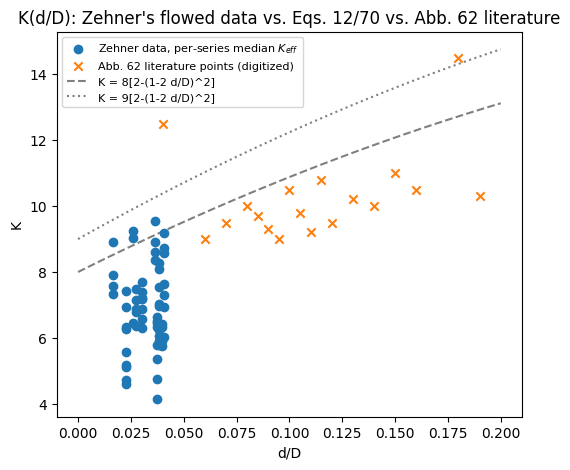

Zehner d/D range: 0.0165 - 0.040873015873015874
Abb. 62 d/D range: 0.04 - 0.19


In [5]:
df["K_eff"] = df["Pe"] / df["residual"]

# block = series, e.g. "TK06/141" -> block "TK06/14"
df["series"] = df["vers_nr"].str.extract(r"(\D+\d+/\d)")[0] + "x"

series_K = df.groupby("series").agg(
    d_over_D=("d_over_D", "mean"),
    K_eff=("K_eff", "median"),
    prefix=("prefix", "first"),
).reset_index()

abb62 = pd.read_csv("data/raw/abb62_K_vs_dD.csv")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(series_K["d_over_D"], series_K["K_eff"], c="C0", label="Zehner data, per-series median $K_{eff}$", zorder=3)
ax.scatter(abb62["d_over_D"], abb62["K"], c="C1", marker="x", label="Abb. 62 literature points (digitized)", zorder=3)
dD_grid = np.linspace(0.0, 0.20, 100)
for k, ls in [(8, "--"), (9, ":")]:
    ax.plot(dD_grid, k * (2 - (1 - 2 * dD_grid) ** 2), ls, color="gray", label=f"K = {k}[2-(1-2 d/D)^2]")
ax.set_xlabel("d/D")
ax.set_ylabel("K")
ax.legend(fontsize=8)
ax.set_title("K(d/D): Zehner's flowed data vs. Eqs. 12/70 vs. Abb. 62 literature")
plt.show()

print("Zehner d/D range:", series_K["d_over_D"].min(), "-", series_K["d_over_D"].max())
print("Abb. 62 d/D range:", abb62["d_over_D"].min(), "-", abb62["d_over_D"].max())

#### 5. Validation: parsimony + extrapolation holdouts

(a) Pareto front of the unconstrained real-data model (#2): log-space MAE vs. complexity. (b) Two extrapolation holdouts: train on everything except copper (KK02/KK10), predict copper; train on everything except the largest d/D bin, predict that bin. Compare each holdout's log-MAE to the in-distribution (#2) MAE — a large gap indicates the discovered form doesn't extrapolate.

In [6]:
def log_mae(y_true, y_pred):
    return np.mean(np.abs(np.log(np.clip(y_pred, 1e-6, None)) - np.log(y_true)))


print("Pareto front (#2, unconstrained real-data fit):")
print(model_real.equations_[["complexity", "loss", "equation"]])

# --- Holdout A: leave-copper-out ---
is_copper = df["prefix"].isin(["KK02", "KK10"])
model_nocopper = PySRRegressor(
    niterations=30, populations=24,
    binary_operators=["+", "-", "*", "/"], unary_operators=["log", "square"],
    maxsize=26, model_selection="best", progress=False, verbosity=0,
    random_state=0, deterministic=True, parallelism="serial",
)
model_nocopper.fit(X_real[~is_copper], y_real[~is_copper])
pred_copper = model_nocopper.predict(X_real[is_copper])
mae_copper_in = log_mae(y_real[~is_copper], model_nocopper.predict(X_real[~is_copper]))
mae_copper_out = log_mae(y_real[is_copper], pred_copper)
print(f"\nLeave-copper-out: in-dist log-MAE={mae_copper_in:.3f}, copper-holdout log-MAE={mae_copper_out:.3f}")
print(model_nocopper.get_best()["equation"])

# --- Holdout B: leave-largest-d/D-bin-out ---
dD_threshold = df["d_over_D"].quantile(0.85)
is_large_dD = df["d_over_D"] >= dD_threshold
model_nolargedD = PySRRegressor(
    niterations=30, populations=24,
    binary_operators=["+", "-", "*", "/"], unary_operators=["log", "square"],
    maxsize=26, model_selection="best", progress=False, verbosity=0,
    random_state=0, deterministic=True, parallelism="serial",
)
model_nolargedD.fit(X_real[~is_large_dD], y_real[~is_large_dD])
pred_large = model_nolargedD.predict(X_real[is_large_dD])
mae_dD_in = log_mae(y_real[~is_large_dD], model_nolargedD.predict(X_real[~is_large_dD]))
mae_dD_out = log_mae(y_real[is_large_dD], pred_large)
print(f"\nLeave-largest-d/D-out (d/D >= {dD_threshold:.4f}): "
      f"in-dist log-MAE={mae_dD_in:.3f}, holdout log-MAE={mae_dD_out:.3f}")
print(model_nolargedD.get_best()["equation"])

Pareto front (#2, unconstrained real-data fit):
    complexity         loss                                           equation
0            1  1142.527100                                           66.35347
1            3   730.332340                                  log_Pe * 27.72074
2            4   446.007300                         square(log_Pe / 0.3003641)
3            5   208.451220                 square(square(log_Pe)) * 1.6046255
4            7    95.034065  square(square(log_Pe - (log_kappa * -0.1351239)))
5            8    82.734480   square(square(log_Pe)) * log(log_Pe + log_kappa)
6           10    79.561516  (square(square(log_Pe)) * log(log_kappa + log_...
7           11    70.756230  square(14.266769 - square(log_Pe - -1.9621387)...
8           13    68.559670  (log_kappa * 11.234438) + (square(square(-2.21...
9           14    48.207737  square(16.884678 - square(log_Pe - -2.2235992)...
10          16    47.847930  ((log(Nu_r) + 11.612304) * (log_kappa + d_over...
11  


Leave-copper-out: in-dist log-MAE=0.074, copper-holdout log-MAE=0.140
((log(Nu_r) + square(((log_Pe / -0.7304292) + 2.2141147) * log_Pe)) - (log_kappa * -5.7691636)) * log_Pe



Leave-largest-d/D-out (d/D >= 0.0381): in-dist log-MAE=0.190, holdout log-MAE=0.137
square((log_Pe + -1.9706635) * 10.103451) - ((log(log_kappa) * -26.437805) - (Nu_r + log_Pe))
